In [2]:
import numpy as np
import pandas as pd

In [2]:
def one_hot_encoding(y, num_classes):
    y = np.array(y).ravel()   # đảm bảo 1D
    classes = np.unique(y)
    class_to_idx = {c:i for i,c in enumerate(classes)}
    y_mapped = np.array([class_to_idx[label] for label in y])

    y_onehot = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        y_onehot[i, y_mapped[i]] = 1
    return y_onehot

In [12]:
class SoftmaxRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.W = None
        self.b = None

    def softmax(self, z):
        exp_z = np.exp(z)
        sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)
        return exp_z / sum_exp_z

    def cross_entropy(self, y, y_pred):
        loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
        return loss

    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        y_pred = self.softmax(z)
        return np.argmax(y_pred, axis=1)
    
    def predict_classes(self, X):
        z = self.predict(X)
        return np.argmax(z, axis=1)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        y_onehot = one_hot_encoding(y, n_classes)

        self.W = np.random.rand(n_features, n_classes)
        self.b = np.random.rand(1, n_classes)

        for epoch in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_pred = self.softmax(z)

            dw = np.dot(X.T, (y_pred - y_onehot)) / n_samples
            db = np.sum(y_pred - y_onehot, axis=0, keepdims=True) / n_samples

            self.W -= self.lr * dw
            self.b -= self.lr * db

            if epoch % 100 == 0:
                loss = self.cross_entropy(y_onehot, y_pred)
                print(f'Epoch {epoch}, Loss: {loss}')

In [13]:
def evaluate_model(y_true, y_pred, num_classes=10):
    accuracy = np.mean(y_true == y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    
    precisions = []
    recalls = []
    f1_scores = []

    for cls in range(num_classes):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = np.mean(f1_scores)

    print("Macro Averages:")
    print(f"  Precision: {macro_precision:.2f}")
    print(f"  Recall:    {macro_recall:.2f}")
    print(f"  F1 Score:  {macro_f1:.2f}")


# Bai 2

In [5]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# land_mines = fetch_ucirepo(id=763) 
  
# # data (as pandas dataframes) 
# X = land_mines.data.features 
# y = land_mines.data.targets 
  
# X.head(10)

In [6]:
# X = X.values
# y = y.values

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# print(X_train.shape, X_test.shape)

In [9]:
# model = SoftmaxRegression(learning_rate=0.05, epochs=100000)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# evaluate_model(y_test, y_pred, num_classes=5)

In [10]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# disp = ConfusionMatrixDisplay(cm)
# disp.plot()

# MNIST

In [3]:
from tensorflow.keras.datasets import mnist

2026-04-21 14:08:38.961125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 14:08:39.002210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Unique labels:  [0 1 2 3 4 5 6 7 8 9]


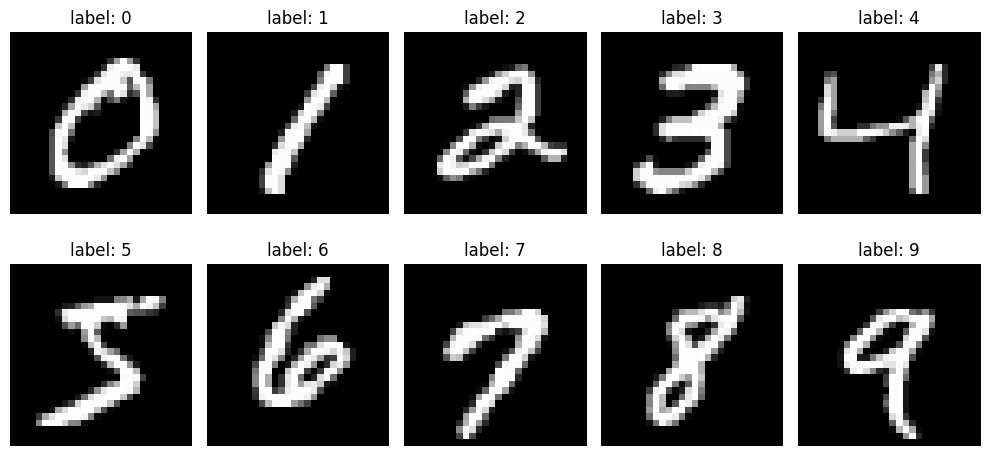

In [8]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(y_train)
print('Unique labels: ', unique_labels)

plt.figure(figsize=(10, 5))
for label in unique_labels:
    index = np.where(y_train == label)[0][0]
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f'label: {label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (60000, 784)
X_test shape : (10000, 784)


In [10]:
def one_hot_encoding(y, num_classes):
    y = np.array(y).ravel()
    classes = np.unique(y)
    class_to_idx = {c : i for i, c in enumerate(classes)}
    y_mapped = np.array([class_to_idx[label] for label in y])

    y_onehot = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        y_onehot[i, y_mapped[i]] = 1
    return y_onehot

In [14]:
model = SoftmaxRegression(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

Epoch 0, Loss: 4.732901962646793
Epoch 100, Loss: 0.8695543675779541
Epoch 200, Loss: 0.6412377059323069
Epoch 300, Loss: 0.5530038321224042
Epoch 400, Loss: 0.5038603800898906
Epoch 500, Loss: 0.4716253705514875
Epoch 600, Loss: 0.44842904699660957
Epoch 700, Loss: 0.43071684561789236
Epoch 800, Loss: 0.4166241988797335
Epoch 900, Loss: 0.40506785117721333


In [15]:
y_pred = model.predict(X_test)
evaluate_model(y_pred=y_pred, y_true=y_test)

Accuracy: 88.84%

Macro Averages:
  Precision: 0.89
  Recall:    0.89
  F1 Score:  0.89


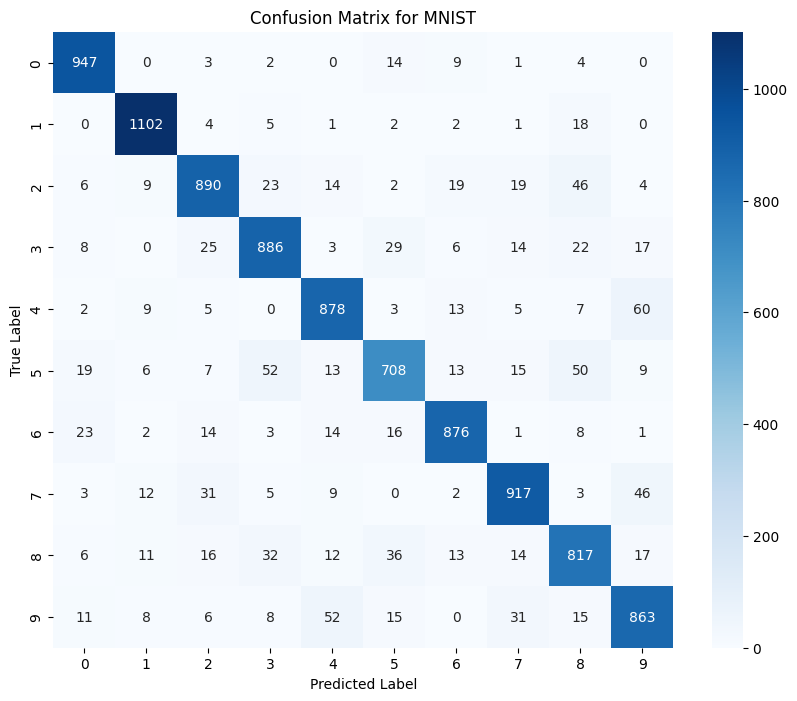

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for MNIST')
    plt.show()
y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred, unique_labels)

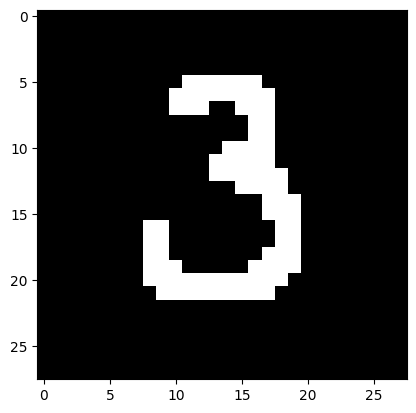

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('3.png')
plt.imshow(img)

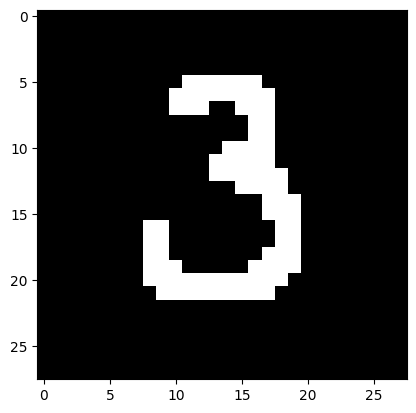

In [5]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')

In [17]:
x = gray_img.reshape(-1) / 255.0

pred_test = model.predict(x)
print("Predicted label for test image:", pred_test[0])

Predicted label for test image: 3


# Bai 4

In [18]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Unique labels:  [0 1 2 3 4 5 6 7 8 9]


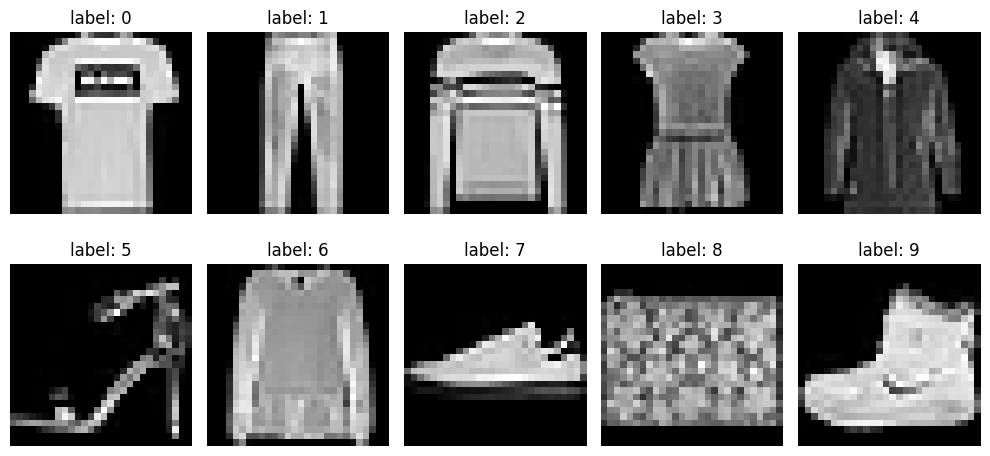

In [19]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(y_train)
print('Unique labels: ', unique_labels)

plt.figure(figsize=(10, 5))
for label in unique_labels:
    index = np.where(y_train == label)[0][0]
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f'label: {label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (60000, 784)
X_test shape : (10000, 784)


In [21]:
model = SoftmaxRegression(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

Epoch 0, Loss: 5.214062676714283
Epoch 100, Loss: 0.9509389518447736
Epoch 200, Loss: 0.7823274115305628
Epoch 300, Loss: 0.7083371562554501
Epoch 400, Loss: 0.6642757522102685
Epoch 500, Loss: 0.6338726645453281
Epoch 600, Loss: 0.6110720599014506
Epoch 700, Loss: 0.5930536022858385
Epoch 800, Loss: 0.578297746982242
Epoch 900, Loss: 0.5658984424462573


Accuracy: 79.41%

Macro Averages:
  Precision: 0.79
  Recall:    0.79
  F1 Score:  0.79


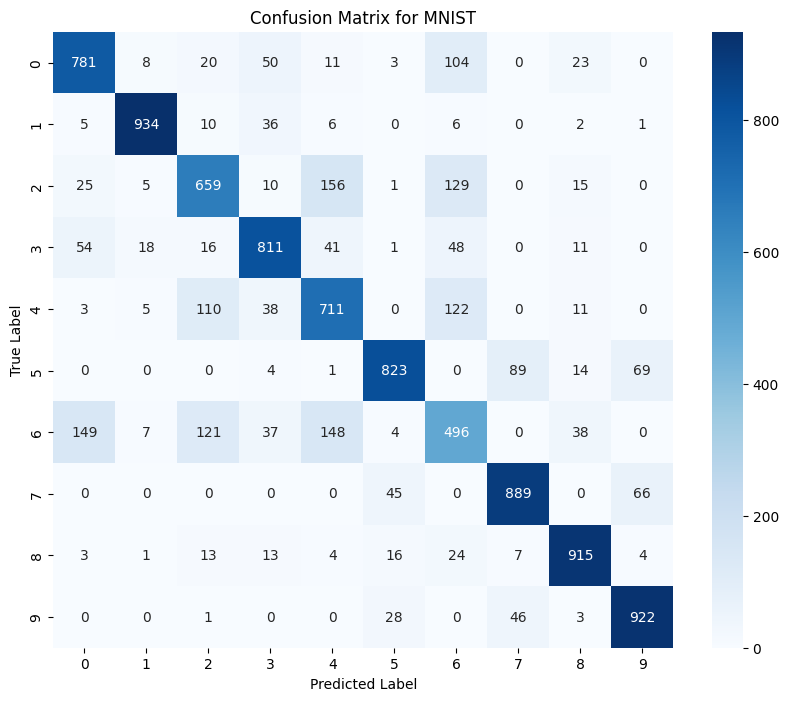

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for MNIST')
    plt.show()
y_pred = model.predict(X_test)
evaluate_model(y_pred=y_pred, y_true=y_test)
plot_confusion_matrix(y_test, y_pred, unique_labels)

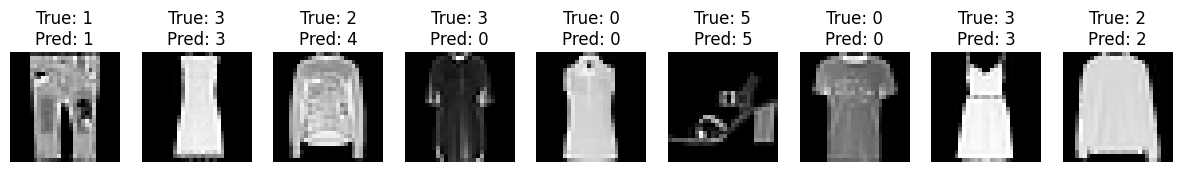

In [23]:
def visualize_predictions(X, y, model, num_samples=5):
    indices = np.random.choice(len(X), num_samples, replace=False)
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: {unique_labels[y[idx]]}\nPred: {unique_labels[model.predict(X[idx].reshape(1, -1))[0]]}")
        plt.axis('off')
    plt.show()
visualize_predictions(X_test, y_test, model, num_samples=9)

# FER

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
test_data = pd.read_csv('test_labels.csv')
train_data = pd.read_csv('train_labels.csv')

test_data.shape, train_data.shape

In [ ]:
test_data.head()

In [ ]:
labels = {
    1: "Surprise",
    2: "Fear",
    3: "Disgust",
    4: "Happiness",
    5: "Sadness",
    6: "Anger",
    7: "Neutral",
}

In [ ]:
X_train_path = train_data["image"].values
y_train = train_data["label"].values

X_test_path = test_data["image"].values
y_test = test_data["label"].values
print(X_train_path[0], y_train[0])
print(X_test_path[0], y_test[0])

In [ ]:
def load_image(image_path, image_size=(36, 36)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, image_size)
    image = image.astype(np.float32) / 255.0
    return image

In [ ]:
unique_labels = np.unique(y_train)
print("Unique labels:", unique_labels)
X_train = []
for i in unique_labels:
    images = X_train_path[y_train == i]
    folder = f"DATASET/train/{i}/"
    for image_path in images:
        image = load_image(folder + image_path)
        X_train.append(image)
X_train = np.array(X_train)
print("X_train shape:", X_train.shape)

In [ ]:
X_test = []
for i in unique_labels:
    images = X_test_path[y_test == i]
    folder = f"DATASET/test/{i}/"
    for image_path in images:
        image = load_image(folder + image_path)
        X_test.append(image)
X_test = np.array(X_test)
print("X_test shape:", X_test.shape)

In [ ]:
def onehot_encode(y):
    num_samples = len(y)
    num_classes = len(np.unique(y))
    y_one_hot = np.zeros((num_samples, num_classes))
    y_one_hot[np.arange(num_samples), y - 1] = 1
    return y_one_hot

y_onehot = onehot_encode(y_train)
y_onehot.shape

In [ ]:
class SoftmaxRegression():
    def __init__(self, learning_rate=0.01, num_epochs=1000, bias=True):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.bias = bias
        self.W = None
        self.b = None
        self.losses = []
    
    def softmax(self, z):
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def cross_entropy(self, y_true, y_pred):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-10), axis=1))
    
    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        y_pred = self.softmax(z)
        return y_pred
    
    def predict_classes(self, X):
        z = self.predict(X)
        return np.argmax(z, axis=1) +  1
    
    def onehot_encode(self, y):
        num_samples = len(y)
        num_classes = len(np.unique(y))
        y_one_hot = np.zeros((num_samples, num_classes))
        y_one_hot[np.arange(num_samples), y - 1] = 1
        return y_one_hot
    
    def fit(self, X, y):
        # suffle the data
        indices = np.arange(X.shape[0])
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        # Flatten the images
        X = X.reshape(X.shape[0], -1)

        num_samples, num_features = X.shape
        num_classes = len(np.unique(y))
        
        # One-hot encoding of labels
        y_one_hot = self.onehot_encode(y)
        
        # Initialize weights and bias
        self.W = np.random.randn(num_features, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))
        
        for epoch in range(self.num_epochs):
            # Forward pass
            z = np.dot(X, self.W) + self.b
            y_pred = self.softmax(z)
            
            # Compute loss
            loss = self.cross_entropy(y_one_hot, y_pred)
            self.losses.append(loss)
            
            # Backward pass
            dz = y_pred - y_one_hot
            dW = np.dot(X.T, dz) / num_samples
            db = np.sum(dz, axis=0, keepdims=True) / num_samples
            
            # Update weights and bias
            self.W -= self.learning_rate * dW
            self.b -= self.learning_rate * db
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")
    def evaluate(self, X, y):
        y_pred = self.predict_classes(X)
        accuracy = np.mean(y_pred == y)
        return accuracy
    def plot_loss(self):
        plt.plot(self.losses)
        plt.title("Loss over epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.show()
    

In [ ]:
myModel = SoftmaxRegression(learning_rate=0.01)
myModel.fit(X_train.reshape(X_train.shape[0], -1), y_train)
myModel.plot_loss()

In [ ]:
# Evaluate the model on the test set
accuracy = myModel.evaluate(X_test.reshape(X_test.shape[0], -1), y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
# Visualize some predictions
def visualize_predictions(X, y, model, num_samples=5):
    indices = np.random.choice(len(X), num_samples, replace=False)
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[idx].reshape(36, 36), cmap='gray')
        plt.title(f"True: {labels[y[idx]]}\nPred: {labels[model.predict_classes(X[idx].reshape(1, -1))[0]]}")
        plt.axis('off')
    plt.show()
visualize_predictions(X_test, y_test, myModel, num_samples=5)

In [ ]:
# draw confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels.values(), yticklabels=labels.values())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
y_pred = myModel.predict_classes(X_test.reshape(X_test.shape[0], -1))
plot_confusion_matrix(y_test, y_pred, labels)